Objectif de l'étude

L'objectif de cette étude est d'analyser les performances des équipes de football et d'en extraire les indicateurs clés.

Pour mener à bien ce travail, nous avons utilisé une base de données Kaggle regroupant des informations sur les joueurs et les clubs de football.

Cette base de données contient les éléments suivants :

Plus de 25 000 matchs
Plus de 10 000 joueurs
11 championnats européens de première division
Les saisons 2008 à 2016
Les attributs des joueurs et des équipes, issus de la série de jeux vidéo FIFA d'EA Sports, avec mises à jour hebdomadaires
La composition des équipes, avec la formation tactique (coordonnées X, Y) des joueurs sur le terrain
Les cotes de paris proposées par jusqu'à 10 bookmakers
Les événements détaillés de plus de 10 000 matchs (types de buts, possession, corners, centres, fautes, cartons, etc.)

Source des donnees:

http://football-data.mx-api.enetscores.com/ : scores, composition, composition de l’équipe et événements

http://www.football-data.co.uk/ : cotes des paris. Cliquez ici pour comprendre le système de nommage des colonnes pour les cotes de pari :

http://sofifa.com/ : attributs des joueurs et des équipes des jeux EA Sports FIFA. FIFA et tous les éléments FIFA sont la propriété d’EA Sports.

In [11]:
# @title Importation des bibliotheques

import pandas as pd
import seaborn as sns
#from google.colab import files
import sqlite3
import matplotlib.pyplot as plt
import statsmodels.api as tb #tableau de regression lineaire
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import kagglehub
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler



In [12]:

# Download latest version
path = kagglehub.dataset_download("hugomathien/soccer")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'soccer' dataset.
Path to dataset files: /kaggle/input/soccer


In [13]:
import os
os.listdir("/root/.cache/kagglehub/datasets/hugomathien/soccer/versions/10")

['database.sqlite']

In [14]:
# @title Importation de la base de donnee
#Connection a ma base de donnee

connection=sqlite3.connect("/root/.cache/kagglehub/datasets/hugomathien/soccer/versions/10/database.sqlite")
#Affichons les tables contenus dans cette base de donnee
nom_table=pd.read_sql_query("SELECT name FROM sqlite_master WHERE type='table'",connection)
print("Table disponible:",nom_table)

Table disponible:                 name
0    sqlite_sequence
1  Player_Attributes
2             Player
3              Match
4             League
5            Country
6               Team
7    Team_Attributes


In [15]:
# @title Extraction des donnees de la table Match
match=pd.read_sql_query("SELECT *FROM Match ",connection)
pd.set_option('display.max_columns',105)
match.head()

,id,country_id,league_id,season,stage,date,match_api_id,home_team_api_id,away_team_api_id,home_team_goal,away_team_goal,home_player_X1,home_player_X2,home_player_X3,home_player_X4,home_player_X5,home_player_X6,home_player_X7,home_player_X8,home_player_X9,home_player_X10,home_player_X11,away_player_X1,away_player_X2,away_player_X3,away_player_X4,away_player_X5,away_player_X6,away_player_X7,away_player_X8,away_player_X9,away_player_X10,away_player_X11,home_player_Y1,home_player_Y2,home_player_Y3,home_player_Y4,home_player_Y5,home_player_Y6,home_player_Y7,home_player_Y8,home_player_Y9,home_player_Y10,home_player_Y11,away_player_Y1,away_player_Y2,away_player_Y3,away_player_Y4,away_player_Y5,away_player_Y6,away_player_Y7,away_player_Y8,...,home_player_9,home_player_10,home_player_11,away_player_1,away_player_2,away_player_3,away_player_4,away_player_5,away_player_6,away_player_7,away_player_8,away_player_9,away_player_10,away_player_11,goal,shoton,shotoff,foulcommit,card,cross,corner,possession,B365H,B365D,B365A,BWH,BWD,BWA,IWH,IWD,IWA,LBH,LBD,LBA,PSH,PSD,PSA,WHH,WHD,WHA,SJH,SJD,SJA,VCH,VCD,VCA,GBH,GBD,GBA,BSH,BSD,BSA
0,1,1,1,2008/2009,1,2008-08-17 00:00:00,492473,9987,9993,1,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,None,None,None,None,None,None,None,1.73,3.40,5.00,1.75,3.35,4.20,1.85,3.2,3.5,1.80,3.3,3.75,NaN,NaN,NaN,1.70,3.30,4.33,1.90,3.3,4.00,1.65,3.40,4.50,1.78,3.25,4.00,1.73,3.40,4.20
1,2,1,1,2008/2009,1,2008-08-16 00:00:00,492474,10000,9994,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,None,None,None,None,None,None,None,1.95,3.20,3.60,1.80,3.30,3.95,1.90,3.2,3.5,1.90,3.2,3.50,NaN,NaN,NaN,1.83,3.30,3.60,1.95,3.3,3.80,2.00,3.25,3.25,1.85,3.25,3.75,1.91,3.25,3.60
2,3,1,1,2008/2009,1,2008-08-16 00:00:00,492475,9984,8635,0,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,None,None,None,None,None,None,None,2.38,3.30,2.75,2.40,3.30,2.55,2.60,3.1,2.3,2.50,3.2,2.50,NaN,NaN,NaN,2.50,3.25,2.40,2.63,3.3,2.50,2.35,3.25,2.65,2.50,3.20,2.50,2.30,3.20,2.75
3,4,1,1,2008/2009,1,2008-08-17 00:00:00,492476,9991,9998,5,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,None,None,None,None,None,None,None,1.44,3.75,7.50,1.40,4.00,6.80,1.40,3.9,6.0,1.44,3.6,6.50,NaN,NaN,NaN,1.44,3.75,6.00,1.44,4.0,7.50,1.45,3.75,6.50,1.50,3.75,5.50,1.44,3.75,6.50
4,5,1,1,2008/2009,1,2008-08-16 00:00:00,492477,7947,9985,1,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,None,None,None,None,None,None,None,5.00,3.50,1.65,5.00,3.50,1.60,4.00,3.3,1.7,4.00,3.4,1.72,NaN,NaN,NaN,4.20,3.40,1.70,4.50,3.5,1.73,4.50,3.40,1.65,4.50,3.50,1.65,4.75,3.30,1.67


In [16]:
#Extraction des elements dans le dataset
match=match[['id','stage','date','match_api_id','home_team_api_id','away_team_api_id','home_team_goal','away_team_goal']]
#convertir la colonne date en type date
match['date']=pd.to_datetime(match['date'])
match.head()

,id,stage,date,match_api_id,home_team_api_id,away_team_api_id,home_team_goal,away_team_goal
0,1,1,2008-08-17,492473,9987,9993,1,1
1,2,1,2008-08-16,492474,10000,9994,0,0
2,3,1,2008-08-16,492475,9984,8635,0,3
3,4,1,2008-08-17,492476,9991,9998,5,0
4,5,1,2008-08-16,492477,7947,9985,1,3


In [17]:
#  @title Extraction de la table Team_attribute
Team_attribute=pd.read_sql_query("SELECT *FROM  Team_Attributes",connection)
Team_attribute['date']=pd.to_datetime(Team_attribute['date'])
Team_attribute.head()

,id,team_fifa_api_id,team_api_id,date,buildUpPlaySpeed,buildUpPlaySpeedClass,buildUpPlayDribbling,buildUpPlayDribblingClass,buildUpPlayPassing,buildUpPlayPassingClass,buildUpPlayPositioningClass,chanceCreationPassing,chanceCreationPassingClass,chanceCreationCrossing,chanceCreationCrossingClass,chanceCreationShooting,chanceCreationShootingClass,chanceCreationPositioningClass,defencePressure,defencePressureClass,defenceAggression,defenceAggressionClass,defenceTeamWidth,defenceTeamWidthClass,defenceDefenderLineClass
0,1,434,9930,2010-02-22,60,Balanced,NaN,Little,50,Mixed,Organised,60,Normal,65,Normal,55,Normal,Organised,50,Medium,55,Press,45,Normal,Cover
1,2,434,9930,2014-09-19,52,Balanced,48.0,Normal,56,Mixed,Organised,54,Normal,63,Normal,64,Normal,Organised,47,Medium,44,Press,54,Normal,Cover
2,3,434,9930,2015-09-10,47,Balanced,41.0,Normal,54,Mixed,Organised,54,Normal,63,Normal,64,Normal,Organised,47,Medium,44,Press,54,Normal,Cover
3,4,77,8485,2010-02-22,70,Fast,NaN,Little,70,Long,Organised,70,Risky,70,Lots,70,Lots,Organised,60,Medium,70,Double,70,Wide,Cover
4,5,77,8485,2011-02-22,47,Balanced,NaN,Little,52,Mixed,Organised,53,Normal,48,Normal,52,Normal,Organised,47,Medium,47,Press,52,Normal,Cover


In [18]:
#La plus petite date et la plus grande date dans Team_attribute
print("Date minimale:",Team_attribute['date'].min())
print("Date maximale:",Team_attribute['date'].max())

Date minimale: 2010-02-22 00:00:00
Date maximale: 2015-09-10 00:00:00


In [19]:
#la plus petite date et la plus grande date dans match
print("Date minimale:",match['date'].min())
print("Date maximale:",match['date'].max())

Date minimale: 2008-07-18 00:00:00
Date maximale: 2016-05-25 00:00:00


In [23]:
#Extraction de la table match des matchs commencant a partir de 2009
match=match[match['date']>'2010-02-22']
print("Date minimale:",match['date'].min())


Date minimale: 2010-02-23 00:00:00


#Premiere partie: Analyse des performances generales des clubs





In [24]:
#Creer une colonne saison dans Match
match['saison']=match['date'].apply(lambda x:f'{x.year}-{x.year+1}' if x.month>7 else f'{x.year-1}-{x.year}')
match.head()

,id,stage,date,match_api_id,home_team_api_id,away_team_api_id,home_team_goal,away_team_goal,saison
413,414,23,2010-02-24,665677,9984,9986,1,0,2009-2010
420,421,24,2010-03-10,665688,9986,9994,4,1,2009-2010
423,424,24,2010-02-24,665694,9999,9987,1,1,2009-2010
433,434,26,2010-03-06,665717,9986,8635,0,2,2009-2010
434,435,26,2010-03-06,665719,9984,9994,4,0,2009-2010


In [25]:
#performance des joeurs a domicile
domicile=match.copy()
domicile.rename(columns={'home_team_api_id':'Team_api_id'},inplace=True)#renommons les colonnes
domicile['Victoire']=(domicile['home_team_goal']>domicile['away_team_goal']).astype(int)
domicile['Nul']=(domicile['home_team_goal']==domicile['away_team_goal']).astype(int)
domicile['Defaite']=(domicile['home_team_goal']<domicile['away_team_goal']).astype(int)
domicile['but_pour']=domicile['home_team_goal']
domicile['but_contre']=domicile['away_team_goal']
domicile.head()

,id,stage,date,match_api_id,Team_api_id,away_team_api_id,home_team_goal,away_team_goal,saison,Victoire,Nul,Defaite,but_pour,but_contre
413,414,23,2010-02-24,665677,9984,9986,1,0,2009-2010,1,0,0,1,0
420,421,24,2010-03-10,665688,9986,9994,4,1,2009-2010,1,0,0,4,1
423,424,24,2010-02-24,665694,9999,9987,1,1,2009-2010,0,1,0,1,1
433,434,26,2010-03-06,665717,9986,8635,0,2,2009-2010,0,0,1,0,2
434,435,26,2010-03-06,665719,9984,9994,4,0,2009-2010,1,0,0,4,0


In [26]:
#performance des joeurs venu de l'exterieur
Exterieur=match.copy()
Exterieur.rename(columns={'away_team_api_id':'Team_api_id'},inplace=True)#renommons les colonnes
Exterieur['Victoire']=(Exterieur['home_team_goal']<Exterieur['away_team_goal']).astype(int)
Exterieur['Nul']=(Exterieur['home_team_goal']==Exterieur['away_team_goal']).astype(int)
Exterieur['Defaite']=(Exterieur['home_team_goal']>Exterieur['away_team_goal']).astype(int)
Exterieur['but_pour']=Exterieur['away_team_goal']
Exterieur['but_contre']=Exterieur['home_team_goal']
Exterieur.head()

,id,stage,date,match_api_id,home_team_api_id,Team_api_id,home_team_goal,away_team_goal,saison,Victoire,Nul,Defaite,but_pour,but_contre
413,414,23,2010-02-24,665677,9984,9986,1,0,2009-2010,0,0,1,0,1
420,421,24,2010-03-10,665688,9986,9994,4,1,2009-2010,0,0,1,1,4
423,424,24,2010-02-24,665694,9999,9987,1,1,2009-2010,0,1,0,1,1
433,434,26,2010-03-06,665717,9986,8635,0,2,2009-2010,1,0,0,2,0
434,435,26,2010-03-06,665719,9984,9994,4,0,2009-2010,0,0,1,0,4


In [27]:
#Concatenation verticale des deux dataframes
le_tous=pd.concat([domicile,Exterieur])
le_tous.head(20)#
le_tous.head()

,id,stage,date,match_api_id,Team_api_id,away_team_api_id,home_team_goal,away_team_goal,saison,Victoire,Nul,Defaite,but_pour,but_contre,home_team_api_id
413,414,23,2010-02-24,665677,9984,9986.0,1,0,2009-2010,1,0,0,1,0,NaN
420,421,24,2010-03-10,665688,9986,9994.0,4,1,2009-2010,1,0,0,4,1,NaN
423,424,24,2010-02-24,665694,9999,9987.0,1,1,2009-2010,0,1,0,1,1,NaN
433,434,26,2010-03-06,665717,9986,8635.0,0,2,2009-2010,0,0,1,0,2,NaN
434,435,26,2010-03-06,665719,9984,9994.0,4,0,2009-2010,1,0,0,4,0,NaN


In [29]:
#Statistique par saison des differentes equipes
statistique_par_saison_par_equipe=le_tous.groupby(['saison','Team_api_id']).agg(
    {
        'Victoire':'sum',
        'Nul':'sum',
        'Defaite':'sum',
        'but_pour':'sum',
        'but_contre':'sum'
    }).reset_index()
statistique_par_saison_par_equipe.head(20)

,saison,Team_api_id,Victoire,Nul,Defaite,but_pour,but_contre
0,2009-2010,1601,6,3,4,17,14
1,2009-2010,1957,5,3,5,9,11
2,2009-2010,2033,2,4,4,16,21
3,2009-2010,2182,10,3,0,24,4
4,2009-2010,2183,5,3,5,12,13
5,2009-2010,2186,4,2,7,12,19
6,2009-2010,4170,4,3,6,14,17
7,2009-2010,6351,0,0,1,1,4
8,2009-2010,6403,2,3,5,12,17
9,2009-2010,6421,2,0,8,8,18


In [30]:
#Ajoutons la difference des buts
statistique_par_saison_par_equipe["Difference de buts"]=statistique_par_saison_par_equipe['but_pour']-statistique_par_saison_par_equipe['but_contre']

In [31]:
#Affichage
statistique_par_saison_par_equipe.head()


,saison,Team_api_id,Victoire,Nul,Defaite,but_pour,but_contre,Difference de buts
0,2009-2010,1601,6,3,4,17,14,3
1,2009-2010,1957,5,3,5,9,11,-2
2,2009-2010,2033,2,4,4,16,21,-5
3,2009-2010,2182,10,3,0,24,4,20
4,2009-2010,2183,5,3,5,12,13,-1


In [32]:
#Calculons le nombre de point par equipe
statistique_par_saison_par_equipe['Points']=3*statistique_par_saison_par_equipe['Victoire']+statistique_par_saison_par_equipe['Nul']

In [33]:
statistique_par_saison_par_equipe.head()

,saison,Team_api_id,Victoire,Nul,Defaite,but_pour,but_contre,Difference de buts,Points
0,2009-2010,1601,6,3,4,17,14,3,21
1,2009-2010,1957,5,3,5,9,11,-2,18
2,2009-2010,2033,2,4,4,16,21,-5,10
3,2009-2010,2182,10,3,0,24,4,20,33
4,2009-2010,2183,5,3,5,12,13,-1,18


In [34]:
#Joyons avec le nom de l'equipe
Team=pd.read_sql_query('SELECT*FROM  Team',connection)
#Extraction du nom de l'equipe
Team=Team[['team_api_id','team_long_name','team_short_name']]
Team.rename(columns={'team_long_name':'Nom_complet',
                     'team_short_name':'Nom_abrege',
                     'team_api_id':'Team_api_id'
},inplace=True)


In [35]:
#jointure
statistique_par_saison_par_equipe=pd.merge(Team,statistique_par_saison_par_equipe,on='Team_api_id')
statistique_par_saison_par_equipe.head(10)

,Team_api_id,Nom_complet,Nom_abrege,saison,Victoire,Nul,Defaite,but_pour,but_contre,Difference de buts,Points
0,9987,KRC Genk,GEN,2009-2010,0,2,3,3,7,-4,2
1,9987,KRC Genk,GEN,2010-2011,20,7,4,67,28,39,67
2,9987,KRC Genk,GEN,2011-2012,12,8,10,60,46,14,44
3,9987,KRC Genk,GEN,2012-2013,15,9,5,60,37,23,54
4,9987,KRC Genk,GEN,2013-2014,0,0,1,1,3,-2,0
5,9987,KRC Genk,GEN,2014-2015,14,10,7,40,27,13,52
6,9987,KRC Genk,GEN,2015-2016,13,6,9,39,28,11,45
7,9993,Beerschot AC,BAC,2009-2010,0,2,2,3,8,-5,2
8,9993,Beerschot AC,BAC,2010-2011,5,11,15,25,43,-18,26
9,9993,Beerschot AC,BAC,2011-2012,9,9,12,46,52,-6,36


Entrer le nom de l'equipe: PSG


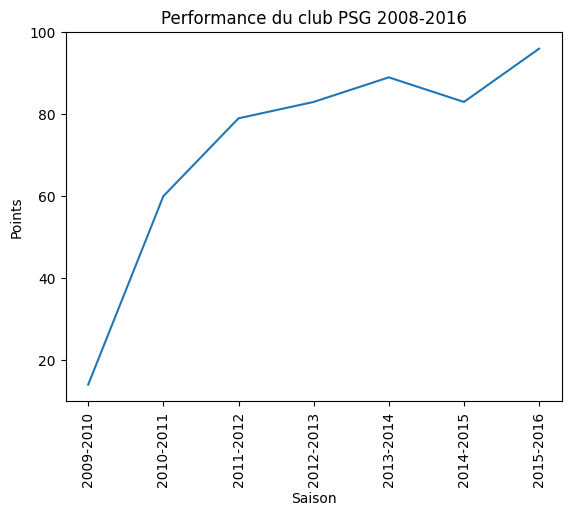

In [45]:
#Visualisation par exemple la performance du PSG au cours des annees
#fonction pour visualiser la performance des equipes
nom_equipe=input("Entrer le nom de l'equipe: ")
def performance(nom_equipe):
  tb=statistique_par_saison_par_equipe[statistique_par_saison_par_equipe['Nom_abrege']==nom_equipe]
  plt.plot(tb['saison'],tb['Points'])
  plt.xticks(rotation=90)
  plt.xlabel('Saison')
  plt.ylabel('Points')
  plt.title(f'Performance du club {nom_equipe} 2008-2016')
  plt.show()
#par exemple visualisons les performances du PSG
performance(nom_equipe)

#l'une des questions qu'on peut se poser cest qu'est ce qui peut expliquer cette performance par exemple?

In [46]:
#Notons les saisons dans Team_attribut
Team_attribute['saison']=Team_attribute['date'].apply(lambda x:f"{x.year}-{x.year+1}"if x.month>7 else f"{x.year-1}-{x.year}")
Team_attribute.rename(columns={'team_api_id':'Team_api_id'},inplace=True)
Team_attribute=Team_attribute[['Team_api_id','buildUpPlaySpeed','buildUpPlaySpeedClass','buildUpPlayDribbling','buildUpPlayDribblingClass','buildUpPlayPassing','buildUpPlayPassingClass','buildUpPlayPositioningClass','chanceCreationPassing','chanceCreationPassingClass','chanceCreationCrossing','chanceCreationCrossingClass','chanceCreationShooting','chanceCreationShootingClass','chanceCreationPositioningClass','defencePressure','defencePressureClass','defenceAggression','defenceAggressionClass','defenceTeamWidth','defenceTeamWidthClass','defenceDefenderLineClass','saison']]
Team_attribute.head()

,Team_api_id,buildUpPlaySpeed,buildUpPlaySpeedClass,buildUpPlayDribbling,buildUpPlayDribblingClass,buildUpPlayPassing,buildUpPlayPassingClass,buildUpPlayPositioningClass,chanceCreationPassing,chanceCreationPassingClass,chanceCreationCrossing,chanceCreationCrossingClass,chanceCreationShooting,chanceCreationShootingClass,chanceCreationPositioningClass,defencePressure,defencePressureClass,defenceAggression,defenceAggressionClass,defenceTeamWidth,defenceTeamWidthClass,defenceDefenderLineClass,saison
0,9930,60,Balanced,NaN,Little,50,Mixed,Organised,60,Normal,65,Normal,55,Normal,Organised,50,Medium,55,Press,45,Normal,Cover,2009-2010
1,9930,52,Balanced,48.0,Normal,56,Mixed,Organised,54,Normal,63,Normal,64,Normal,Organised,47,Medium,44,Press,54,Normal,Cover,2014-2015
2,9930,47,Balanced,41.0,Normal,54,Mixed,Organised,54,Normal,63,Normal,64,Normal,Organised,47,Medium,44,Press,54,Normal,Cover,2015-2016
3,8485,70,Fast,NaN,Little,70,Long,Organised,70,Risky,70,Lots,70,Lots,Organised,60,Medium,70,Double,70,Wide,Cover,2009-2010
4,8485,47,Balanced,NaN,Little,52,Mixed,Organised,53,Normal,48,Normal,52,Normal,Organised,47,Medium,47,Press,52,Normal,Cover,2010-2011


In [47]:
#Ajoutons les performances des joeurs
statistique_par_saison_par_equipe=pd.merge(statistique_par_saison_par_equipe,Team_attribute,on=['Team_api_id','saison'])
statistique_par_saison_par_equipe.head()

,Team_api_id,Nom_complet,Nom_abrege,saison,Victoire,Nul,Defaite,but_pour,but_contre,Difference de buts,Points,buildUpPlaySpeed,buildUpPlaySpeedClass,buildUpPlayDribbling,buildUpPlayDribblingClass,buildUpPlayPassing,buildUpPlayPassingClass,buildUpPlayPositioningClass,chanceCreationPassing,chanceCreationPassingClass,chanceCreationCrossing,chanceCreationCrossingClass,chanceCreationShooting,chanceCreationShootingClass,chanceCreationPositioningClass,defencePressure,defencePressureClass,defenceAggression,defenceAggressionClass,defenceTeamWidth,defenceTeamWidthClass,defenceDefenderLineClass
0,9987,KRC Genk,GEN,2009-2010,0,2,3,3,7,-4,2,45,Balanced,NaN,Little,45,Mixed,Organised,50,Normal,35,Normal,60,Normal,Organised,70,High,65,Press,70,Wide,Cover
1,9987,KRC Genk,GEN,2010-2011,20,7,4,67,28,39,67,66,Balanced,NaN,Little,52,Mixed,Organised,65,Normal,66,Normal,51,Normal,Organised,48,Medium,47,Press,54,Normal,Offside Trap
2,9987,KRC Genk,GEN,2011-2012,12,8,10,60,46,14,44,53,Balanced,NaN,Little,55,Mixed,Organised,55,Normal,48,Normal,56,Normal,Organised,47,Medium,45,Press,55,Normal,Cover
3,9987,KRC Genk,GEN,2013-2014,0,0,1,1,3,-2,0,58,Balanced,NaN,Little,38,Mixed,Organised,67,Risky,48,Normal,56,Normal,Organised,47,Medium,45,Press,55,Normal,Cover
4,9987,KRC Genk,GEN,2014-2015,14,10,7,40,27,13,52,58,Balanced,52.0,Normal,38,Mixed,Organised,67,Risky,48,Normal,56,Normal,Organised,47,Medium,45,Press,55,Normal,Cover


In [48]:
#Verifions les valeurs manquantes
statistique_par_saison_par_equipe.isnull().sum()

,0
Team_api_id,0
Nom_complet,0
Nom_abrege,0
saison,0
Victoire,0
Nul,0
Defaite,0
but_pour,0
but_contre,0
Difference de buts,0


In [49]:
#copie dans stats
stat=statistique_par_saison_par_equipe.copy()

In [50]:
#remplacons les manquantes par de la colonne buildUpPlayDribbling la moyenne
moyenne=stat['buildUpPlayDribbling'].mean()
moyenne
stat['buildUpPlayDribbling'].fillna(moyenne,inplace=True)

/tmp/ipykernel_2755/3901505491.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  stat['buildUpPlayDribbling'].fillna(moyenne,inplace=True)


In [51]:
stat.head()

,Team_api_id,Nom_complet,Nom_abrege,saison,Victoire,Nul,Defaite,but_pour,but_contre,Difference de buts,Points,buildUpPlaySpeed,buildUpPlaySpeedClass,buildUpPlayDribbling,buildUpPlayDribblingClass,buildUpPlayPassing,buildUpPlayPassingClass,buildUpPlayPositioningClass,chanceCreationPassing,chanceCreationPassingClass,chanceCreationCrossing,chanceCreationCrossingClass,chanceCreationShooting,chanceCreationShootingClass,chanceCreationPositioningClass,defencePressure,defencePressureClass,defenceAggression,defenceAggressionClass,defenceTeamWidth,defenceTeamWidthClass,defenceDefenderLineClass
0,9987,KRC Genk,GEN,2009-2010,0,2,3,3,7,-4,2,45,Balanced,49.025568,Little,45,Mixed,Organised,50,Normal,35,Normal,60,Normal,Organised,70,High,65,Press,70,Wide,Cover
1,9987,KRC Genk,GEN,2010-2011,20,7,4,67,28,39,67,66,Balanced,49.025568,Little,52,Mixed,Organised,65,Normal,66,Normal,51,Normal,Organised,48,Medium,47,Press,54,Normal,Offside Trap
2,9987,KRC Genk,GEN,2011-2012,12,8,10,60,46,14,44,53,Balanced,49.025568,Little,55,Mixed,Organised,55,Normal,48,Normal,56,Normal,Organised,47,Medium,45,Press,55,Normal,Cover
3,9987,KRC Genk,GEN,2013-2014,0,0,1,1,3,-2,0,58,Balanced,49.025568,Little,38,Mixed,Organised,67,Risky,48,Normal,56,Normal,Organised,47,Medium,45,Press,55,Normal,Cover
4,9987,KRC Genk,GEN,2014-2015,14,10,7,40,27,13,52,58,Balanced,52.000000,Normal,38,Mixed,Organised,67,Risky,48,Normal,56,Normal,Organised,47,Medium,45,Press,55,Normal,Cover


In [52]:
stat.isnull().sum()

,0
Team_api_id,0
Nom_complet,0
Nom_abrege,0
saison,0
Victoire,0
Nul,0
Defaite,0
but_pour,0
but_contre,0
Difference de buts,0


In [53]:
#une petite description
stat.describe()

,Team_api_id,Victoire,Nul,Defaite,but_pour,but_contre,Difference de buts,Points,buildUpPlaySpeed,buildUpPlayDribbling,buildUpPlayPassing,chanceCreationPassing,chanceCreationCrossing,chanceCreationShooting,defencePressure,defenceAggression,defenceTeamWidth
count,1082.00000,1082.000000,1082.000000,1082.000000,1082.000000,1082.000000,1082.000000,1082.000000,1082.000000,1082.000000,1082.000000,1082.000000,1082.000000,1082.000000,1082.000000,1082.000000,1082.000000
mean,9750.03512,11.573937,7.762477,11.362292,42.006470,41.503697,0.502773,42.484288,52.524030,49.025568,47.876155,52.404806,53.847505,54.141405,46.527726,49.647874,52.280961
std,12423.31297,6.271869,3.663450,5.857385,19.630371,17.579277,21.975398,19.744956,11.955742,5.516837,11.053373,10.517625,11.194845,10.569158,10.398519,9.998651,9.624715
min,1601.00000,0.000000,0.000000,0.000000,0.000000,0.000000,-61.000000,0.000000,20.000000,24.000000,20.000000,21.000000,20.000000,22.000000,23.000000,24.000000,30.000000
25%,8472.00000,7.000000,5.000000,7.000000,31.000000,30.000000,-13.000000,30.000000,45.000000,49.025568,39.000000,46.250000,48.000000,48.000000,39.000000,44.000000,48.000000
50%,8721.00000,11.000000,8.000000,12.000000,42.000000,44.000000,-2.000000,43.000000,53.000000,49.025568,49.000000,52.000000,53.000000,54.000000,46.000000,48.000000,52.000000
75%,9929.25000,15.000000,10.000000,16.000000,53.000000,54.000000,10.000000,54.000000,62.750000,49.025568,55.000000,60.000000,63.000000,62.000000,53.000000,57.000000,59.000000
max,274581.00000,33.000000,19.000000,27.000000,121.000000,98.000000,89.000000,102.000000,80.000000,77.000000,80.000000,80.000000,80.000000,80.000000,72.000000,72.000000,73.000000


In [63]:
# @title Affichage des differentes statistiques descriptives
#Meilleurs equipes au cours des saisons
meilleirs_club=stat.groupby(['saison']).agg({
    'Points':'max'

})
meilleirs=pd.merge(meilleirs_club,stat,on=['saison','Points'],how='inner')
meilleirs

,saison,Points,Team_api_id,Nom_complet,Nom_abrege,Victoire,Nul,Defaite,but_pour,but_contre,Difference de buts,buildUpPlaySpeed,buildUpPlaySpeedClass,buildUpPlayDribbling,buildUpPlayDribblingClass,buildUpPlayPassing,buildUpPlayPassingClass,buildUpPlayPositioningClass,chanceCreationPassing,chanceCreationPassingClass,chanceCreationCrossing,chanceCreationCrossingClass,chanceCreationShooting,chanceCreationShootingClass,chanceCreationPositioningClass,defencePressure,defencePressureClass,defenceAggression,defenceAggressionClass,defenceTeamWidth,defenceTeamWidthClass,defenceDefenderLineClass
0,2009-2010,43,9931,FC Basel,BAS,14,1,2,45,20,25,40,Balanced,49.025568,Little,45,Mixed,Organised,50,Normal,65,Normal,50,Normal,Organised,60,Medium,60,Press,60,Normal,Cover
1,2010-2011,97,8548,Rangers,RAN,31,4,5,91,30,61,51,Balanced,49.025568,Little,33,Short,Organised,48,Normal,67,Lots,79,Lots,Organised,46,Medium,47,Press,51,Normal,Cover
2,2011-2012,100,8633,Real Madrid CF,REA,32,4,2,121,32,89,45,Balanced,49.025568,Little,35,Mixed,Free Form,71,Risky,54,Normal,73,Lots,Free Form,49,Medium,60,Press,68,Wide,Cover
3,2013-2014,102,9885,Juventus,JUV,33,3,2,80,23,57,39,Balanced,49.025568,Little,33,Short,Organised,51,Normal,63,Normal,72,Lots,Free Form,66,Medium,67,Double,36,Normal,Cover
4,2014-2015,94,8634,FC Barcelona,BAR,30,4,4,110,21,89,35,Balanced,35.000000,Normal,32,Short,Free Form,37,Normal,31,Little,35,Normal,Free Form,61,Medium,63,Press,65,Normal,Cover
5,2015-2016,96,9847,Paris Saint-Germain,PSG,30,6,2,102,19,83,49,Balanced,47.000000,Normal,34,Mixed,Organised,62,Normal,61,Normal,35,Normal,Organised,57,Medium,53,Press,56,Normal,Cover


In [64]:
#les club qui ont fait les plus faible performance
faibles_club=stat.groupby(['saison']).agg({
    'Points':'min'
})
faibles_club=pd.merge(meilleirs_club,stat,on=['saison','Points'],how='inner')
faibles_club

,saison,Points,Team_api_id,Nom_complet,Nom_abrege,Victoire,Nul,Defaite,but_pour,but_contre,Difference de buts,buildUpPlaySpeed,buildUpPlaySpeedClass,buildUpPlayDribbling,buildUpPlayDribblingClass,buildUpPlayPassing,buildUpPlayPassingClass,buildUpPlayPositioningClass,chanceCreationPassing,chanceCreationPassingClass,chanceCreationCrossing,chanceCreationCrossingClass,chanceCreationShooting,chanceCreationShootingClass,chanceCreationPositioningClass,defencePressure,defencePressureClass,defenceAggression,defenceAggressionClass,defenceTeamWidth,defenceTeamWidthClass,defenceDefenderLineClass
0,2009-2010,43,9931,FC Basel,BAS,14,1,2,45,20,25,40,Balanced,49.025568,Little,45,Mixed,Organised,50,Normal,65,Normal,50,Normal,Organised,60,Medium,60,Press,60,Normal,Cover
1,2010-2011,97,8548,Rangers,RAN,31,4,5,91,30,61,51,Balanced,49.025568,Little,33,Short,Organised,48,Normal,67,Lots,79,Lots,Organised,46,Medium,47,Press,51,Normal,Cover
2,2011-2012,100,8633,Real Madrid CF,REA,32,4,2,121,32,89,45,Balanced,49.025568,Little,35,Mixed,Free Form,71,Risky,54,Normal,73,Lots,Free Form,49,Medium,60,Press,68,Wide,Cover
3,2013-2014,102,9885,Juventus,JUV,33,3,2,80,23,57,39,Balanced,49.025568,Little,33,Short,Organised,51,Normal,63,Normal,72,Lots,Free Form,66,Medium,67,Double,36,Normal,Cover
4,2014-2015,94,8634,FC Barcelona,BAR,30,4,4,110,21,89,35,Balanced,35.000000,Normal,32,Short,Free Form,37,Normal,31,Little,35,Normal,Free Form,61,Medium,63,Press,65,Normal,Cover
5,2015-2016,96,9847,Paris Saint-Germain,PSG,30,6,2,102,19,83,49,Balanced,47.000000,Normal,34,Mixed,Organised,62,Normal,61,Normal,35,Normal,Organised,57,Medium,53,Press,56,Normal,Cover


In [56]:
#Point moyen gagne par les  club au cours des saisons

point_moyen=stat.groupby(['saison']).agg({
    'Points':'mean'
})
point_moyen

,Points
saison,
2009-2010,16.372973
2010-2011,48.161290
2011-2012,47.440217
2013-2014,45.782857
2014-2015,49.079545
2015-2016,48.875000


In [57]:
#ecart des valeurs autour de la moyenne
ecart=stat.groupby(['saison'])['Points'].std()
ecart

,Points
saison,
2009-2010,7.969802
2010-2011,15.297617
2011-2012,15.783256
2013-2014,20.603223
2014-2015,16.759967
2015-2016,15.939394


Text(1, 54.0, 'Q3=54.0')

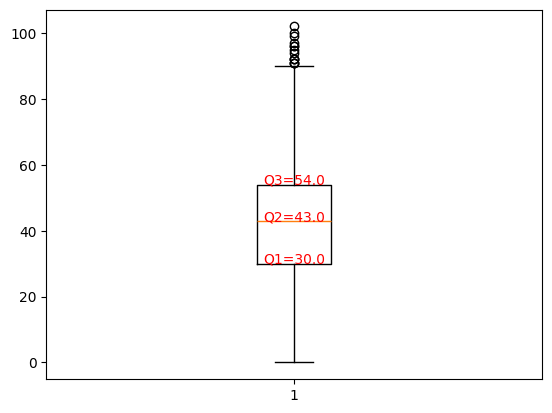

In [58]:
# @title Boxplot
plt.boxplot(stat['Points'])
plt.text(1,stat['Points'].quantile(0.25),f"Q1={stat['Points'].quantile(0.25)}",ha='center',color='red')
plt.text(1,stat['Points'].quantile(0.5),f"Q2={stat['Points'].quantile(0.5)}",ha='center',color='red')
plt.text(1,stat['Points'].quantile(0.75),f"Q3={stat['Points'].quantile(0.75)}",ha='center',color='red')

In [59]:
#nombre de buts moyens marquer par equipe au cours des saisons
but_moyen=stat.groupby(['Team_api_id']).agg({
    'but_pour':'mean'
}).reset_index()
but_moyen_r=pd.merge(but_moyen,Team,on='Team_api_id').sort_values(by='but_pour',ascending=False)
but_moyen_r.head()

,Team_api_id,but_pour,Nom_complet,Nom_abrege
124,8633,99.666667,Real Madrid CF,REA
125,8634,95.333333,FC Barcelona,BAR
211,9925,78.666667,Celtic,CEL
214,9931,72.500000,FC Basel,BAS
171,9823,72.500000,FC Bayern Munich,BMU


In [60]:
#equipe qui ont encaisse le moins de buts
but_moins=stat.groupby(['saison']).agg({
    'but_contre':'min'
})
but_moins=pd.merge(but_moins,stat,on=['saison','but_contre'],how='inner')
but_moins.head()

,saison,but_contre,Team_api_id,Nom_complet,Nom_abrege,Victoire,Nul,Defaite,but_pour,Difference de buts,Points,buildUpPlaySpeed,buildUpPlaySpeedClass,buildUpPlayDribbling,buildUpPlayDribblingClass,buildUpPlayPassing,buildUpPlayPassingClass,buildUpPlayPositioningClass,chanceCreationPassing,chanceCreationPassingClass,chanceCreationCrossing,chanceCreationCrossingClass,chanceCreationShooting,chanceCreationShootingClass,chanceCreationPositioningClass,defencePressure,defencePressureClass,defenceAggression,defenceAggressionClass,defenceTeamWidth,defenceTeamWidthClass,defenceDefenderLineClass
0,2009-2010,2,8635,RSC Anderlecht,AND,5,0,0,14,12,15,50,Balanced,49.025568,Little,35,Mixed,Organised,70,Risky,50,Normal,60,Normal,Organised,70,High,50,Press,70,Wide,Cover
1,2009-2010,2,9991,KAA Gent,GEN,3,1,0,6,4,10,70,Fast,49.025568,Little,65,Mixed,Organised,60,Normal,50,Normal,60,Normal,Organised,45,Medium,50,Press,40,Normal,Cover
2,2010-2011,5,8244,Widzew Łódź,LOD,0,0,1,0,-5,0,63,Balanced,49.025568,Little,48,Mixed,Organised,48,Normal,68,Lots,53,Normal,Organised,37,Medium,58,Press,63,Normal,Cover
3,2011-2012,14,7955,Neuchâtel Xamax,XAM,7,5,3,22,8,26,49,Balanced,49.025568,Little,50,Mixed,Organised,39,Normal,48,Normal,34,Normal,Organised,34,Medium,31,Contain,51,Normal,Cover
4,2013-2014,0,10000,SV Zulte-Waregem,ZUL,1,0,0,2,2,3,54,Balanced,49.025568,Little,51,Mixed,Organised,47,Normal,52,Normal,32,Little,Organised,44,Medium,58,Press,37,Normal,Cover


In [61]:
#equipes qui a marquer le plus de buts
buts_plus=stat.groupby(['saison']).agg({
    'but_pour':'max'
})
buts_plus=pd.merge(buts_plus,stat,on=['saison','but_pour'],how='inner')
buts_plus.head(20)

,saison,but_pour,Team_api_id,Nom_complet,Nom_abrege,Victoire,Nul,Defaite,but_contre,Difference de buts,Points,buildUpPlaySpeed,buildUpPlaySpeedClass,buildUpPlayDribbling,buildUpPlayDribblingClass,buildUpPlayPassing,buildUpPlayPassingClass,buildUpPlayPositioningClass,chanceCreationPassing,chanceCreationPassingClass,chanceCreationCrossing,chanceCreationCrossingClass,chanceCreationShooting,chanceCreationShootingClass,chanceCreationPositioningClass,defencePressure,defencePressureClass,defenceAggression,defenceAggressionClass,defenceTeamWidth,defenceTeamWidthClass,defenceDefenderLineClass
0,2009-2010,45,9931,FC Basel,BAS,14,1,2,20,25,43,40,Balanced,49.025568,Little,45,Mixed,Organised,50,Normal,65,Normal,50,Normal,Organised,60,Medium,60,Press,60,Normal,Cover
1,2010-2011,102,8633,Real Madrid CF,REA,29,5,4,33,69,92,54,Balanced,49.025568,Little,39,Mixed,Free Form,67,Risky,60,Normal,67,Lots,Free Form,68,High,55,Press,55,Normal,Cover
2,2011-2012,121,8633,Real Madrid CF,REA,32,4,2,32,89,100,45,Balanced,49.025568,Little,35,Mixed,Free Form,71,Risky,54,Normal,73,Lots,Free Form,49,Medium,60,Press,68,Wide,Cover
3,2013-2014,104,8633,Real Madrid CF,REA,27,6,5,38,66,87,50,Balanced,49.025568,Little,41,Mixed,Organised,68,Risky,54,Normal,72,Lots,Free Form,39,Medium,49,Press,65,Normal,Cover
4,2014-2015,118,8633,Real Madrid CF,REA,30,2,6,38,80,92,50,Balanced,54.000000,Normal,41,Mixed,Organised,68,Risky,54,Normal,69,Lots,Free Form,39,Medium,49,Press,65,Normal,Cover
5,2015-2016,112,8634,FC Barcelona,BAR,29,4,5,29,83,91,36,Balanced,35.000000,Normal,51,Mixed,Free Form,36,Normal,49,Normal,56,Normal,Free Form,61,Medium,65,Press,65,Normal,Cover


#MODELISATION ET ANALYSE MULTIVARIE


In [92]:
cat_cols = stat.select_dtypes(include=['object', 'category']).columns.tolist()
cat_cols.remove('Nom_complet')
cat_cols.remove('Nom_abrege')
cat_cols.remove('saison')

df_result = stat.copy()

for col in cat_cols:
    ref = stat[col].iloc[0]  # première modalité = référence -> 1, le reste -> 0
    df_result[col] = (stat[col] == ref).astype(int)

display(df_result)

,Team_api_id,Nom_complet,Nom_abrege,saison,Victoire,Nul,Defaite,but_pour,but_contre,Difference de buts,Points,buildUpPlaySpeed,buildUpPlaySpeedClass,buildUpPlayDribbling,buildUpPlayDribblingClass,buildUpPlayPassing,buildUpPlayPassingClass,buildUpPlayPositioningClass,chanceCreationPassing,chanceCreationPassingClass,chanceCreationCrossing,chanceCreationCrossingClass,chanceCreationShooting,chanceCreationShootingClass,chanceCreationPositioningClass,defencePressure,defencePressureClass,defenceAggression,defenceAggressionClass,defenceTeamWidth,defenceTeamWidthClass,defenceDefenderLineClass
0,9987,KRC Genk,GEN,2009-2010,0,2,3,3,7,-4,2,45,1,49.025568,1,45,1,1,50,1,35,1,60,1,1,70,1,65,1,70,1,1
1,9987,KRC Genk,GEN,2010-2011,20,7,4,67,28,39,67,66,1,49.025568,1,52,1,1,65,1,66,1,51,1,1,48,0,47,1,54,0,0
2,9987,KRC Genk,GEN,2011-2012,12,8,10,60,46,14,44,53,1,49.025568,1,55,1,1,55,1,48,1,56,1,1,47,0,45,1,55,0,1
3,9987,KRC Genk,GEN,2013-2014,0,0,1,1,3,-2,0,58,1,49.025568,1,38,1,1,67,0,48,1,56,1,1,47,0,45,1,55,0,1
4,9987,KRC Genk,GEN,2014-2015,14,10,7,40,27,13,52,58,1,52.000000,0,38,1,1,67,0,48,1,56,1,1,47,0,45,1,55,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1077,10191,FC Thun,THU,2014-2015,12,13,10,48,48,0,49,58,1,59.000000,0,35,1,1,64,1,36,1,66,1,1,47,0,45,1,53,0,1
1078,10191,FC Thun,THU,2015-2016,9,11,14,39,47,-8,38,58,1,59.000000,0,35,1,1,64,1,36,1,66,1,1,47,0,45,1,53,0,1
1079,9777,Servette FC,SER,2011-2012,13,5,16,41,55,-14,44,48,1,49.025568,1,51,1,1,53,1,66,1,45,1,1,49,0,45,1,49,0,1
1080,7730,FC Lausanne-Sports,LAU,2011-2012,8,7,20,32,60,-28,31,37,1,49.025568,1,49,1,1,52,1,60,1,48,1,1,43,0,43,1,55,0,1


In [93]:
df_result.drop('Nom_complet',inplace=True,axis=1)
df_result.drop('Nom_abrege',inplace=True,axis=1)
df_result.drop('saison',inplace=True,axis=1)

In [94]:
#TEST D'hausman
display(df_result)


,Team_api_id,Victoire,Nul,Defaite,but_pour,but_contre,Difference de buts,Points,buildUpPlaySpeed,buildUpPlaySpeedClass,buildUpPlayDribbling,buildUpPlayDribblingClass,buildUpPlayPassing,buildUpPlayPassingClass,buildUpPlayPositioningClass,chanceCreationPassing,chanceCreationPassingClass,chanceCreationCrossing,chanceCreationCrossingClass,chanceCreationShooting,chanceCreationShootingClass,chanceCreationPositioningClass,defencePressure,defencePressureClass,defenceAggression,defenceAggressionClass,defenceTeamWidth,defenceTeamWidthClass,defenceDefenderLineClass
0,9987,0,2,3,3,7,-4,2,45,1,49.025568,1,45,1,1,50,1,35,1,60,1,1,70,1,65,1,70,1,1
1,9987,20,7,4,67,28,39,67,66,1,49.025568,1,52,1,1,65,1,66,1,51,1,1,48,0,47,1,54,0,0
2,9987,12,8,10,60,46,14,44,53,1,49.025568,1,55,1,1,55,1,48,1,56,1,1,47,0,45,1,55,0,1
3,9987,0,0,1,1,3,-2,0,58,1,49.025568,1,38,1,1,67,0,48,1,56,1,1,47,0,45,1,55,0,1
4,9987,14,10,7,40,27,13,52,58,1,52.000000,0,38,1,1,67,0,48,1,56,1,1,47,0,45,1,55,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1077,10191,12,13,10,48,48,0,49,58,1,59.000000,0,35,1,1,64,1,36,1,66,1,1,47,0,45,1,53,0,1
1078,10191,9,11,14,39,47,-8,38,58,1,59.000000,0,35,1,1,64,1,36,1,66,1,1,47,0,45,1,53,0,1
1079,9777,13,5,16,41,55,-14,44,48,1,49.025568,1,51,1,1,53,1,66,1,45,1,1,49,0,45,1,49,0,1
1080,7730,8,7,20,32,60,-28,31,37,1,49.025568,1,49,1,1,52,1,60,1,48,1,1,43,0,43,1,55,0,1


In [95]:
pip install linearmodels

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 13.4 MB/s eta 0:00:00


In [128]:
# Import the required library for panel models
from linearmodels import PanelOLS, RandomEffects
import statsmodels.api as sm
import pandas as pd # Ensure pandas is imported

# Prepare the data for panel regression
# Extract the starting year from the 'saison' string and convert it to an integer.
stat_r['saison_numeric'] = pd.to_datetime(stat_r['saison'].str.split('-').str[0], errors='coerce').dt.year

# Ensure 'saison_numeric' is an integer and handle any potential NaNs
if stat_r['saison_numeric'].isnull().any():
    median_year = stat_r['saison_numeric'].median()
    stat_r['saison_numeric'].fillna(median_year, inplace=True)
    print(f"Warning: Filled NaN values in 'saison_numeric' with median year: {int(median_year)}")

stat_r['saison_numeric'] = stat_r['saison_numeric'].astype(int)

# Set 'Team_api_id' as the entity index and 'saison_numeric' as the time index.
# stat_r is assumed to be already defined by previous cells (specifically llROUQmIMR_G)
stat_panel = stat_r.set_index(['Team_api_id', 'saison_numeric']).sort_index()

# Define the dependent variable
Y = stat_panel['Points']

# Define the independent variables
# These are the variables identified as significant or considered for the model
X_cols = [
 'chanceCreationCrossing',
 'defencePressure',
 'Fast_x',
 'Little_y',
 'Long_i',
 'Mixed_i',
 'Free Form_z',
 'Normal_h',
 'Risky_h',
 'Little_t',
 'Lots_f',
 'Free Form_e',
 'Deep_d',
 'High_d',
 'Contain_c',
 'Double_c',
 'Narrow_b',
 'Normal_b',
 'Cover_a']
X = stat_panel[X_cols]

# Add a constant to the independent variables
X = sm.add_constant(X)

### Fixed Effects Model

In [129]:
# Estimate the Fixed Effects (Within) model
fe_model = PanelOLS(Y, X, entity_effects=True)
fe_res = fe_model.fit()
print(fe_res)

                          PanelOLS Estimation Summary                           
Dep. Variable:                 Points   R-squared:                        0.3888
Estimator:                   PanelOLS   R-squared (Between):             -0.0749
No. Observations:                1082   R-squared (Within):               0.3888
Date:                Tue, Sep 15 2026   R-squared (Overall):              0.1501
Time:                        14:38:36   Log-likelihood                   -4149.2
Cov. Estimator:            Unadjusted                                           
                                        F-statistic:                      26.454
Entities:                         273   P-value                           0.0000
Avg Obs:                       3.9634   Distribution:                  F(19,790)
Min Obs:                       1.0000                                           
Max Obs:                       6.0000   F-statistic (robust):             26.454
                            

### Random Effects Model

In [130]:
# Estimate the Random Effects model
re_model = RandomEffects(Y, X)
re_res = re_model.fit()
print(re_res)

                        RandomEffects Estimation Summary                        
Dep. Variable:                 Points   R-squared:                        0.2526
Estimator:              RandomEffects   R-squared (Between):              0.1837
No. Observations:                1082   R-squared (Within):               0.3524
Date:                Tue, Sep 15 2026   R-squared (Overall):              0.2473
Time:                        14:39:01   Log-likelihood                   -4393.4
Cov. Estimator:            Unadjusted                                           
                                        F-statistic:                      18.887
Entities:                         273   P-value                           0.0000
Avg Obs:                       3.9634   Distribution:                 F(19,1062)
Min Obs:                       1.0000                                           
Max Obs:                       6.0000   F-statistic (robust):             24.160
                            

### Hausman Test

Now, let's perform the Hausman test to choose between the Fixed Effects and Random Effects models. The null hypothesis of the Hausman test is that the random effects model is consistent and efficient. If the p-value is small (e.g., < 0.05), we reject the null hypothesis, suggesting that fixed effects model is more appropriate.

In [132]:
import numpy as np
from scipy import stats

def hausman_test(fe_res, re_res):
    common_params = [p for p in fe_res.params.index if p in re_res.params.index and p != 'const']

    b_fe = fe_res.params[common_params]
    b_re = re_res.params[common_params]

    v_fe = fe_res.cov.loc[common_params, common_params]
    v_re = re_res.cov.loc[common_params, common_params]

    diff = b_fe - b_re
    var_diff = v_fe - v_re

    stat = float(diff.T @ np.linalg.inv(var_diff.values) @ diff)
    dof = len(common_params)
    p_value = 1 - stats.chi2.cdf(stat, dof)

    print(f"Hausman statistic: {stat:.4f}")
    print(f"Degrees of freedom: {dof}")
    print(f"P-value: {p_value:.4f}")

    if p_value < 0.05:
        print("=> Rejette H0 : préférer le modèle à Effets Fixes (FE)")
    else:
        print("=> Ne rejette pas H0 : le modèle à Effets Aléatoires (RE) est valide et plus efficace")

hausman_test(fe_res, re_res)

Hausman statistic: 422.4620
Degrees of freedom: 19
P-value: 0.0000
=> Rejette H0 : préférer le modèle à Effets Fixes (FE)
